<a href="https://colab.research.google.com/github/NikethnaSri-AI/ai-learning-notebooks/blob/main/instruction__fine_tuning_prac.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q --no-cache-dir numpy==1.26.4 pandas==2.2.2
%pip install -q --no-cache-dir torch==2.4.1 \
    --index-url https://download.pytorch.org/whl/cpu
%pip install -q --no-cache-dir \
    transformers==4.42.3 \
    datasets==2.20.0 \
    trl==0.9.6 \
    peft==0.11.1 \
    accelerate \
    evaluate

In [3]:
import torch
from datasets import load_dataset
from transformers import (AutoModelForCausalLM, AutoTokenizer)
from peft import (LoraConfig, TaskType, get_peft_model)
from trl import (SFTConfig, SFTTrainer, DataCollatorForCompletionOnlyLM)

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(device)

cpu


### Dataset

In [5]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/WzOT_CwDALWedTtXjwH7bA/CodeAlpaca-20k.json

--2026-08-11 13:42:57--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/WzOT_CwDALWedTtXjwH7bA/CodeAlpaca-20k.json
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6957007 (6.6M) [application/json]
Saving to: ‘CodeAlpaca-20k.json’

CodeAlpaca-20k.json 100%[===================>]   6.63M  8.45MB/s    in 0.8s    

2026-08-11 13:42:59 (8.45 MB/s) - ‘CodeAlpaca-20k.json’ saved [6957007/6957007]



In [6]:
dataset = load_dataset("json", data_files="CodeAlpaca-20k.json", split="train")

Generating train split: 0 examples [00:00, ? examples/s]

In [7]:
dataset[1000]

{'output': 's = "Hello world" \ns = s[::-1] \nprint(s)',
 'instruction': 'Reverse the string given in the input',
 'input': 'Hello world'}

In [8]:
dataset = dataset.filter(lambda example: example["input"] == '')

Filter:   0%|          | 0/20022 [00:00<?, ? examples/s]

In [9]:
dataset = dataset.shuffle(seed=42)

In [10]:
dataset

Dataset({
    features: ['output', 'instruction', 'input'],
    num_rows: 9764
})

In [11]:
dataset_split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = dataset_split['train']
test_dataset = dataset_split['test']
dataset_split

DatasetDict({
    train: Dataset({
        features: ['output', 'instruction', 'input'],
        num_rows: 7811
    })
    test: Dataset({
        features: ['output', 'instruction', 'input'],
        num_rows: 1953
    })
})

In [12]:
tiny_test_dataset=test_dataset.select(range(10))
tiny_train_dataset=train_dataset.select(range(10))

### Model and tokenizer

In [13]:
# Base model
model = AutoModelForCausalLM.from_pretrained("facebook/opt-350m").to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/663M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

In [14]:
tokenizer = AutoTokenizer.from_pretrained("facebook/opt-350m", padding_side='left')

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

In [15]:
tokenizer.eos_token

'</s>'

### Data Preprocessing

In [20]:
def formatting_prompts_func(mydataset):
    output_texts = []

    for i in range(len(mydataset["instruction"])):
        text = (
            f"Instruction:\n{mydataset['instruction'][i]}"
            f"\n\nResponse:\n{mydataset['output'][i]}"
            f"{tokenizer.eos_token}"
        )
        output_texts.append(text)

    return output_texts

In [21]:
def formatting_prompts_func_no_response(mydataset):
    output_texts = []

    for i in range(len(mydataset["instruction"])):
        text = (
            f"Instruction:\n{mydataset['instruction'][i]}"
            f"\n\nResponse:\n"
        )
        output_texts.append(text)

    return output_texts

### Testing Base Model

In [22]:
sample = tiny_test_dataset[0]

prompt = (
    f"Instruction:\n{sample['instruction']}"
    f"\n\nResponse:\n"
)

inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=60,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

base_response = tokenizer.decode(
    outputs[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True
)
print("Instruction:")
print(sample["instruction"])
print("\nExpected response:")
print(sample["output"])
print("\nBase model response:")
print(base_response)

Instruction:
Name the most important benefit of using a database system.

Expected response:
The most important benefit of using a database system is the ability to store and retrieve data quickly and easily. Database systems also provide support for data security, data integrity, and concurrently accessing and modifying data from multiple systems.

Base model response:

The most important benefit of using a database system is the ability to store and retrieve data in a way that is easy to use and easy to maintain.

Response:

The most important benefit of using a database system is the ability to store and retrieve data in a way that is easy


### Fine-tuning with LoRA


In [23]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 1,572,864 || all params: 332,769,280 || trainable%: 0.4727


In [24]:
model.print_trainable_parameters()

trainable params: 1,572,864 || all params: 332,769,280 || trainable%: 0.4727


In [25]:
response_template = "Response:\n"
collator = DataCollatorForCompletionOnlyLM(
    response_template,
    tokenizer=tokenizer
)

In [26]:
tiny_train_dataset = train_dataset.select(range(10))
tiny_test_dataset = test_dataset.select(range(10))

In [27]:
training_args = SFTConfig(
    output_dir="./instruction-tuning-output",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    max_seq_length=512,
    do_eval=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_strategy="no",
    logging_steps=1
)

In [28]:
trainer = SFTTrainer(
    model=model,
    train_dataset=tiny_train_dataset,
    eval_dataset=tiny_test_dataset,
    formatting_func=formatting_prompts_func,
    args=training_args,
    packing=False,
    data_collator=collator
)

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

### Model Training

In [29]:
trainer.train()

Step,Training Loss
1,3.807000
2,0.609300
3,3.484800
4,1.424700
5,5.080100
6,6.720700
7,3.979200
8,2.177600
9,1.891900
10,2.899600


TrainOutput(global_step=10, training_loss=3.2074835121631624, metrics={'train_runtime': 46.5034, 'train_samples_per_second': 0.215, 'train_steps_per_second': 0.215, 'total_flos': 2290640289792.0, 'train_loss': 3.2074835121631624, 'epoch': 1.0})

### Test the Fine-Tuned Model

In [30]:
fine_tuned_model = trainer.model
fine_tuned_model.eval()
inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = fine_tuned_model.generate(
        **inputs,
        max_new_tokens=60,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

fine_tuned_response = tokenizer.decode(
    outputs[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True
)

In [31]:
print("Instruction:")
print(sample["instruction"])
print("\nExpected response:")
print(sample["output"])
print("\nBefore fine-tuning:")
print(base_response)
print("\nAfter instruction fine-tuning:")
print(fine_tuned_response)

Instruction:
Name the most important benefit of using a database system.

Expected response:
The most important benefit of using a database system is the ability to store and retrieve data quickly and easily. Database systems also provide support for data security, data integrity, and concurrently accessing and modifying data from multiple systems.

Before fine-tuning:

The most important benefit of using a database system is the ability to store and retrieve data in a way that is easy to use and easy to maintain.

Response:

The most important benefit of using a database system is the ability to store and retrieve data in a way that is easy

After instruction fine-tuning:

The most important benefit of using a database system is the ability to store and retrieve data in a way that is easy to use and easy to understand.

Response:

The most important benefit of using a database system is the ability to store and retrieve data in a way that is easy


In [32]:
eval_results = trainer.evaluate()
print(eval_results)

{'eval_loss': 2.153789758682251, 'eval_runtime': 15.8017, 'eval_samples_per_second': 0.633, 'eval_steps_per_second': 0.633, 'epoch': 1.0}


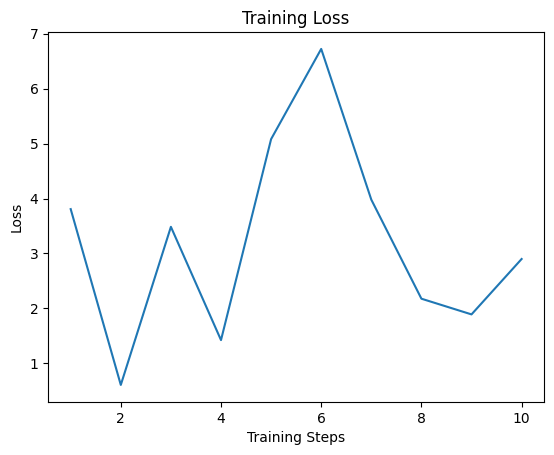

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
log = pd.DataFrame(trainer.state.log_history)
train_log = log[log["loss"].notna()]
plt.plot(train_log["step"], train_log["loss"])
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [34]:
for i in range(3):
    sample = tiny_test_dataset[i]
    prompt = (
        f"Instruction:\n{sample['instruction']}"
        f"\n\nResponse:\n"
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        outputs = fine_tuned_model.generate(
            **inputs,
            max_new_tokens=60,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    print("\nInstruction:", sample["instruction"])
    print("Expected:", sample["output"])
    print("Fine-tuned:", response)
    print("-" * 50)


Instruction: Name the most important benefit of using a database system.
Expected: The most important benefit of using a database system is the ability to store and retrieve data quickly and easily. Database systems also provide support for data security, data integrity, and concurrently accessing and modifying data from multiple systems.
Fine-tuned: 
The most important benefit of using a database system is the ability to store and retrieve data in a way that is easy to use and easy to understand.

Response:

The most important benefit of using a database system is the ability to store and retrieve data in a way that is easy
--------------------------------------------------

Instruction: Come up with a Java program that checks if one string is a substring of another.
Expected: public static boolean isSubstring(String s, String x) {
    int i = 0, j = 0;
    while (i < s.length() && j < x.length()) {
        if (s.charAt(i) == x.charAt(j)) {
            i++;
            j++;
        }